# Fragrance shelf-life stability - Predictive model

**Objective 2:** **Predictive Model** — Build a model to predict `stability_months` from manufacturing sensor readings, enabling the Quality team to anticipate shelf-life at production time rather than waiting months for lab results. It must describes the confidence in the predictions and helps the team to explain the variations of stability. 

Here I combined the ETL process and the predictive modeling into a single workflow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Data cleaning

Rules applied, in order:
1. Drop `plant_location` (identical to `plant_country`).
2. Convert the Fahrenheit rows to Celsius.
3. Replace the fixed sensor fault codes (210 °C, -1 bar, 860 g/cm³, pH 14) with NaN.
4. Replace any negative pressure, torque or flow with NaN (safety net).

No rows are dropped: every batch has a valid target.

In [2]:
raw_data = pd.read_csv('data_set.csv')
print('Raw shape:', raw_data.shape)

clean = raw_data.copy()
clean['event_timestamp'] = pd.to_datetime(clean['event_timestamp'], format='mixed', dayfirst=True)

#plant_location and plant_country are identical (one plant per country)
assert (clean.groupby('plant_country')['plant_location'].nunique() == 1).all()
clean = clean.drop(columns=['plant_location'])

#Temperature: converting the F rows to C
is_f = clean['temp_unit'] == 'F'
print(f'Rows in F converted to C: {is_f.sum()}')
clean['reaction_temperature_celsius'] = clean['temp_value']
clean.loc[is_f, 'reaction_temperature_celsius'] = (clean.loc[is_f, 'temp_value'] - 32) * 5 / 9
clean = clean.drop(columns=['temp_value', 'temp_unit'])

#Sensor fault codes found in the EDA -> NaN
fault_codes = {
    'reaction_temperature_celsius': 210,
    'vessel_pressure_bar': -1,
    'density_g_cm3': 860,
    'ph_level': 14
}
print('\nFault codes replaced by NaN:')
for col, code in fault_codes.items():
    mask = clean[col].round(2) == code
    clean.loc[mask, col] = np.nan
    print(f'  {col} == {code}: {mask.sum()}')

#Physically impossible values -> NaN
cannot_be_negative = ['vessel_pressure_bar', 'mixing_torque_nm', 'mass_flow_rate_kg_h']
print('\nNegative values replaced by NaN:')
for col in cannot_be_negative:
    mask = clean[col] < 0
    clean.loc[mask, col] = np.nan
    print(f'  {col}: {mask.sum()}')

sensor_cols = ['reaction_temperature_celsius', 'vessel_pressure_bar', 'refractive_index',
               'density_g_cm3', 'ph_level', 'mixing_torque_nm', 'mass_flow_rate_kg_h']
clean = clean[['batch_id', 'event_timestamp', 'plant_country', 'production_line_id']
              + sensor_cols
              + ['stability_months', 'purity_grade', 'oxidation_risk_flag']]

print('\nMissing values after cleaning:')
print(clean[sensor_cols].isna().sum())
print('\nSensor ranges after cleaning:')
print(clean[sensor_cols].describe().loc[['min', 'max']].T)

clean.to_csv('data_clean.csv', index=False)
print('\nClean shape:', clean.shape)

Raw shape: (259200, 16)
Rows in F converted to C: 1506

Fault codes replaced by NaN:
  reaction_temperature_celsius == 210: 526
  vessel_pressure_bar == -1: 544
  density_g_cm3 == 860: 558
  ph_level == 14: 543

Negative values replaced by NaN:
  vessel_pressure_bar: 0
  mixing_torque_nm: 0
  mass_flow_rate_kg_h: 0

Missing values after cleaning:
reaction_temperature_celsius    23696
vessel_pressure_bar             23519
refractive_index                22971
density_g_cm3                   23601
ph_level                        23480
mixing_torque_nm                22880
mass_flow_rate_kg_h             23162
dtype: int64

Sensor ranges after cleaning:
                                     min         max
reaction_temperature_celsius   78.955600   93.126400
vessel_pressure_bar             1.989310    2.619600
refractive_index                1.437219    1.483709
density_g_cm3                   0.837224    0.885914
ph_level                        4.945060    6.111014
mixing_torque_nm       

## 2. Features, target and split

`purity_grade` and `oxidation_risk_flag` are derived from `stability_months`, so they are excluded from the inputs (data leakage). `low_torque` is the flag found in the root cause analysis; it mainly helps the linear model, which cannot learn a threshold on its own.

In [3]:
data = clean.copy()
cat_cols = ['plant_country', 'production_line_id']

data['low_torque'] = (data['mixing_torque_nm'] < 11.4).astype(int)

X = data[sensor_cols + ['low_torque'] + cat_cols]
y = data['stability_months']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)}  Test: {len(X_test)}')

Train: 207360  Test: 51840


## 3. Missing values and categorical columns

Missing sensor values are filled with the median of the **training set** (computed once, applied to both sets, so the test set does not leak into the model). The two categorical columns are one-hot encoded.

In [4]:
#Missing numerical values: median of the training set
medians = X_train[sensor_cols].median()
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

#Categorical columns: one-hot encoding
X_train = pd.get_dummies(X_train, columns=cat_cols)
X_test = pd.get_dummies(X_test, columns=cat_cols)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print('Number of features:', X_train.shape[1])

Number of features: 23


## 4. Models

Three models, from simplest to most flexible, compared on the same 20% test set.

In [5]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred),
        'Within ±1 month %': np.mean(np.abs(y_test - pred) <= 1) * 100,
    })
    print(f'{name} done')

results = pd.DataFrame(results).round(3)
results

Linear Regression done
Random Forest done
Gradient Boosting done


,Model,MAE,RMSE,R2,Within ±1 month %
0,Linear Regression,1.027,1.291,0.601,56.408
1,Random Forest,0.799,1.032,0.745,68.991
2,Gradient Boosting,0.769,0.982,0.769,70.625


In [6]:
best_name = results.sort_values('MAE').iloc[0]['Model']
best_model = models[best_name]
best_pred = predictions[best_name]
print('Best model:', best_name)

Best model: Gradient Boosting


Gradient Boosting is the best model: mean error of ~0.77 months, R² of ~0.77 and ~71% of the batches predicted within ±1 month. Linear regression lags (R² ~0.60) because the torque effect is a threshold, not a slope.

## 5. What explains the variation

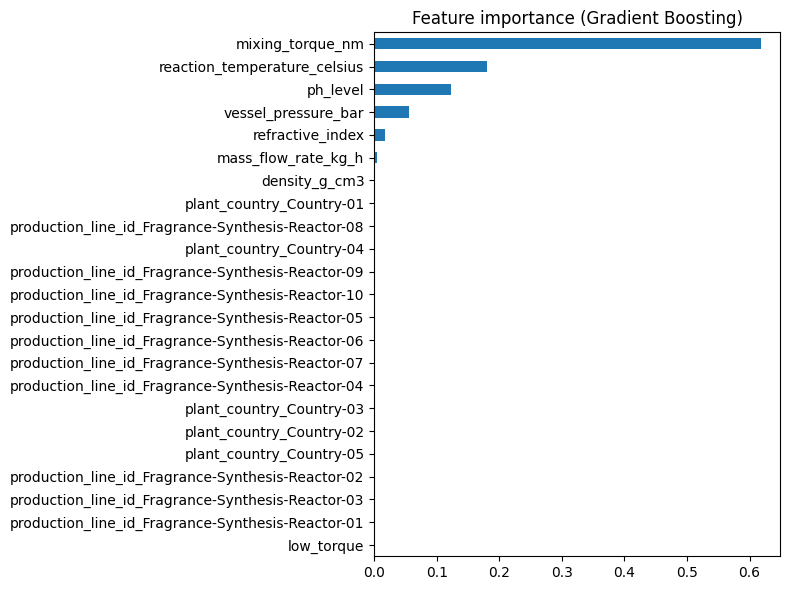

In [7]:
importance = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(8, 6))
importance.plot(kind='barh')
plt.title(f'Feature importance ({best_name})')
plt.tight_layout()
plt.show()

In [8]:
#pH and pressure had ~0 correlation but show up in the importance: checking for a non-linear effect
for col in ['ph_level', 'vessel_pressure_bar']:
    bins = pd.cut(data[col], 10)
    print(f'\nMean stability by {col} bin:')
    print(data.groupby(bins, observed=True)['stability_months'].mean().round(3))


Mean stability by ph_level bin:
ph_level
(4.944, 5.062]    20.564
(5.062, 5.178]    21.007
(5.178, 5.295]    21.634
(5.295, 5.411]    22.056
(5.411, 5.528]    22.255
(5.528, 5.645]    22.184
(5.645, 5.761]    21.890
(5.761, 5.878]    21.336
(5.878, 5.994]    20.642
(5.994, 6.111]    19.666
Name: stability_months, dtype: float64

Mean stability by vessel_pressure_bar bin:
vessel_pressure_bar
(1.989, 2.052]    20.851
(2.052, 2.115]    21.179
(2.115, 2.178]    21.491
(2.178, 2.241]    21.830
(2.241, 2.304]    22.161
(2.304, 2.367]    22.112
(2.367, 2.431]    21.774
(2.431, 2.494]    21.457
(2.494, 2.557]    21.112
(2.557, 2.62]     20.931
Name: stability_months, dtype: float64


Torque dominates, temperature is second. The plant and reactor dummies have zero importance: once the sensors are known, the plant or reactor does not add anything. The reduced stability in Plant-04 is fully explained by what its stirrers are doing, not by the site itself.

`low_torque` also has zero importance for the tree model, since it can split on the torque value directly.

## 6. Predicted vs actual

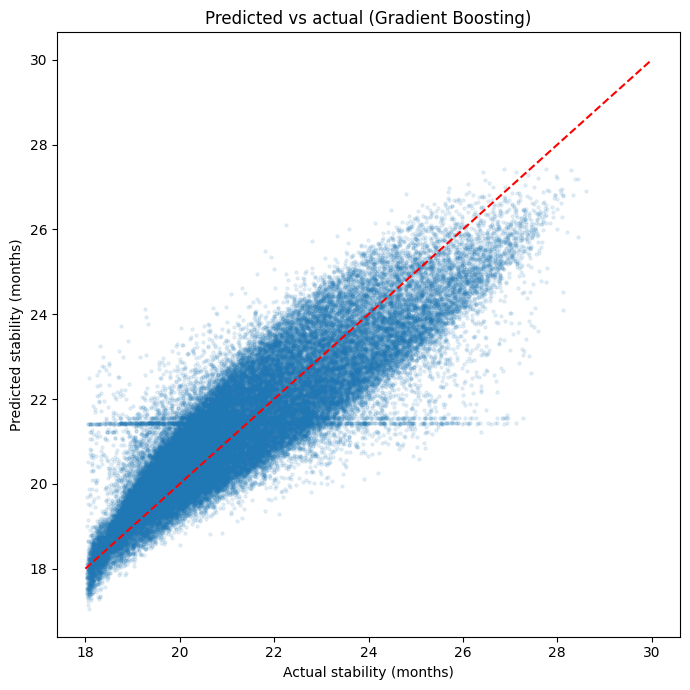

In [9]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_pred, alpha=0.1, s=5)
plt.plot([18, 30], [18, 30], 'r--')
plt.xlabel('Actual stability (months)')
plt.ylabel('Predicted stability (months)')
plt.title(f'Predicted vs actual ({best_name})')
plt.tight_layout()
plt.show()

The predictions are tight for the low-stability batches (18-19 months) and wider for the rest. Two things to be aware of:

- The horizontal band at ~21.4 months are the batches with no torque reading. With the main feature filled by the median, the model can only predict the average. The torque sensor is the one that must be reliable for the model to be useful.
- Above ~26 months the model under-predicts: these batches are rare in the training data.

## 7. Confidence of the predictions

In [10]:
errors = np.abs(y_test - best_pred)
print(f'80% of the predictions are within ±{np.percentile(errors, 80):.2f} months of the real value')
print(f'95% of the predictions are within ±{np.percentile(errors, 95):.2f} months of the real value')

#Same check on the low-torque batches only
low_mask = X_test['low_torque'] == 1
print(f'\nWithin ±1 month, all batches:        {np.mean(errors <= 1) * 100:.1f}%')
print(f'Within ±1 month, low-torque batches: {np.mean(errors[low_mask] <= 1) * 100:.1f}%')

80% of the predictions are within ±1.21 months of the real value
95% of the predictions are within ±1.82 months of the real value

Within ±1 month, all batches:        70.6%
Within ±1 month, low-torque batches: 99.3%


## 8. Conclusions

- The best model (Gradient Boosting) predicts shelf-life with a mean error of ~0.8 months and explains ~77% of the variation. 80% of predictions land within ±1.2 months and 95% within ±1.8 months of the lab value.
- On the problem batches (low torque) the model is close to perfect, so it can flag them at production time instead of waiting months for the lab result.
- The drivers, in order: mixing torque, reaction temperature, then pH and pressure (non-linear, weak). Plant and reactor identity add nothing once the sensors are known.
- Limitations: when the torque reading is missing the prediction falls back to the average; very high stability batches (>26 months) are under-predicted.